In [1]:
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()
from sklearn.cluster import KMeans
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width'
                                                , 'petal_length', 'petal_width'])
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [2]:
KM = KMeans(n_clusters=3, max_iter=300,init='k-means++', random_state=0)
KM.fit(iris_df) #훈련/테스트 분할 x
KM.labels_ #각 데이터가 속한 군집 번호

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [3]:

iris_df['target'] = iris.target #실제값
iris_df['cluster'] = KM.labels_ #모델이 정한 군집번호
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1


In [4]:
iris_df.groupby(['target','cluster'])['sepal_length'].count()

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64

# 군집의 평가 : 실루엣 계수

In [5]:
from sklearn.metrics import silhouette_score, silhouette_samples
iris_df['silhouette_coeff'] = silhouette_samples(iris.data, iris_df['cluster'])
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,0,1,0.852582
1,4.9,3.0,1.4,0.2,0,1,0.814916
2,4.7,3.2,1.3,0.2,0,1,0.828797
3,4.6,3.1,1.5,0.2,0,1,0.804352
4,5.0,3.6,1.4,0.2,0,1,0.848918


In [6]:
silhouette_score(iris.data, iris_df['cluster'])

0.5511916046195919

In [7]:
score_sample = silhouette_samples(iris.data, iris_df['cluster'])
score_sample

array([ 0.85258191,  0.8149163 ,  0.82879659,  0.80435199,  0.84891774,
        0.7477614 ,  0.82109757,  0.8534934 ,  0.75127806,  0.82475199,
        0.80269525,  0.83540396,  0.80996716,  0.74535637,  0.70224038,
        0.64338856,  0.77526857,  0.85063272,  0.70636742,  0.81987458,
        0.78364122,  0.82546665,  0.79244412,  0.79345251,  0.77426479,
        0.79799564,  0.83296108,  0.84162136,  0.84325046,  0.81723402,
        0.8145665 ,  0.79849826,  0.76227879,  0.72184605,  0.82822866,
        0.83179477,  0.79374024,  0.84148042,  0.76779363,  0.84992603,
        0.84902387,  0.63767419,  0.78589195,  0.79963167,  0.74629437,
        0.80915172,  0.81295565,  0.81844011,  0.81783314,  0.85168255,
       -0.02672203,  0.36827154,  0.08489767,  0.59610609,  0.35669884,
        0.59416206,  0.27019063,  0.27245453,  0.32755642,  0.58167084,
        0.38107057,  0.58665651,  0.55085685,  0.47851679,  0.56757079,
        0.30479553,  0.5596951 ,  0.61137194,  0.46029717,  0.61

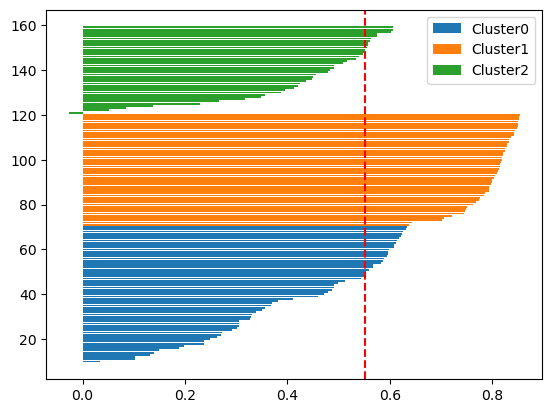

In [22]:
# 실루엣계수 시각화
import matplotlib.pyplot as plt
y_lower = 10

for i in range(3):
  cluster_i = score_sample[iris_df['cluster'] == i]
  cluster_i.sort()
  y_upper = y_lower + len(cluster_i)
  plt.barh(range(y_lower, y_upper), cluster_i, label=f'Cluster{i}')
  y_lower = y_upper
  
avg_score = silhouette_score(iris.data, iris_df['cluster'])
plt.axvline(avg_score, color='red', linestyle='--')
plt.legend()
plt.show()

# k 값의 선택을 위한 스크리 차트

In [23]:
scree_df = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
sse_values = []

k_values = range(1,11)
for k in k_values:
  kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=0)
  kmeans.fit(scree_df)
  sse_values.append(kmeans.inertia_)

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

In [10]:
sse_values

[681.3706,
 152.34795176035792,
 78.85566582597728,
 57.228473214285714,
 49.82774055829229,
 42.42154575309748,
 34.420191786283894,
 30.064593073593073,
 28.715856536394465,
 27.46211879129643]

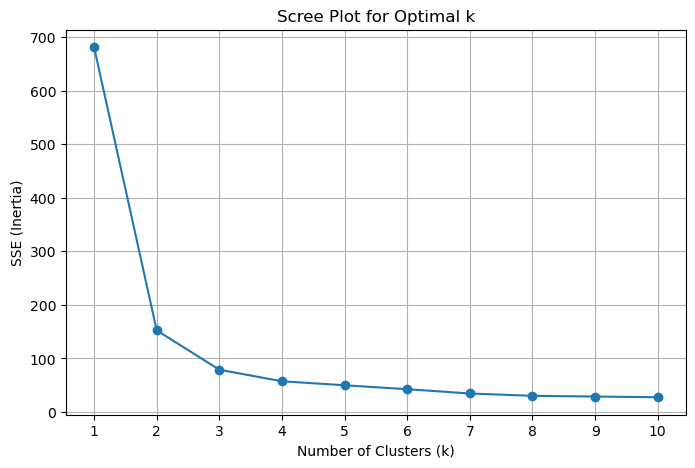

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(k_values, sse_values, marker='o')
plt.xticks(k_values)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Scree Plot for Optimal k')
plt.grid(True)
plt.show()

# iris_df의 차원축소

In [12]:
from sklearn.decomposition import PCA

# PCA 객체 생성 (주성분 2개로 축소)
pca = PCA(n_components=2)

# 데이터 변환
X_pca = pca.fit_transform(iris.data)

# 설명된 분산 비율 확인
print(pca.explained_variance_ratio_)

[0.92461872 0.05306648]


In [13]:
X_pca

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [14]:
iris_df['pca_x'] = X_pca[:, 0]
iris_df['pca_y'] = X_pca[:, 1]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,0.852582,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,0.814916,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,0.828797,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,0.804352,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,0.848918,-2.728717,0.326755


In [15]:
iris_df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target',
       'cluster', 'silhouette_coeff', 'pca_x', 'pca_y'],
      dtype='str')

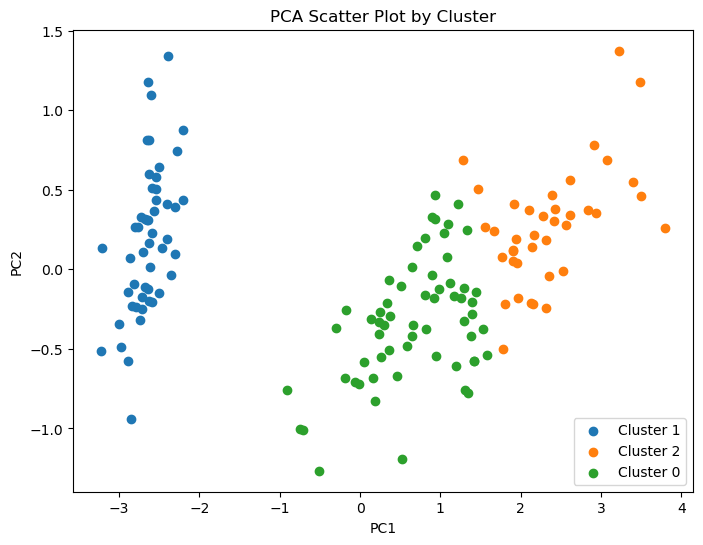

In [25]:
plt.figure(figsize=(8,6))

for c in iris_df['cluster'].unique():
    subset = iris_df[iris_df['cluster'] == c]
    plt.scatter(subset['pca_x'], subset['pca_y'], label=f'Cluster {c}')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Scatter Plot by Cluster')
plt.legend()
plt.show()

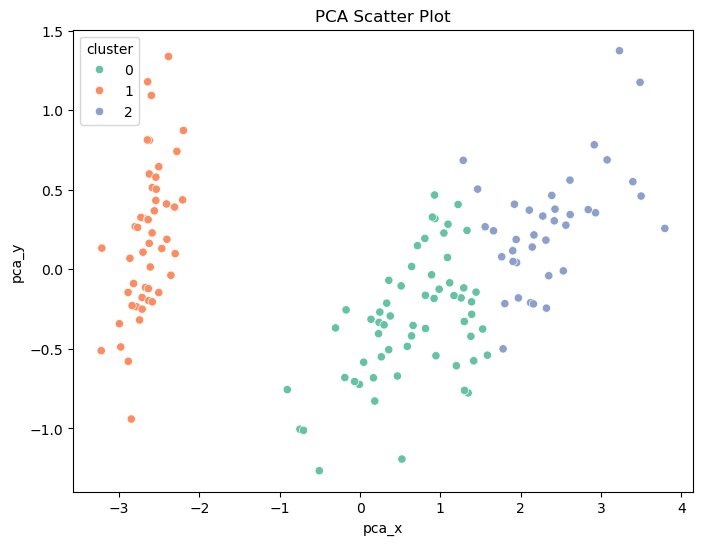

In [26]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='pca_x',
    y='pca_y',
    hue='cluster',   # 클러스터 없으면 제거
    data=iris_df,
    palette='Set2'
)
plt.title('PCA Scatter Plot')
plt.show()

# iris_df 피처를 스케일링

In [27]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [28]:
# iris_df 피처를 스케일링
# iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(iris.data)

pca_scaled = PCA(n_components=2)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

print("스케일링 후 설명분산비율:", pca_scaled.explained_variance_ratio_)
print("스케일링 후 누적설명분산:", sum(pca_scaled.explained_variance_ratio_))

스케일링 후 설명분산비율: [0.72962445 0.22850762]
스케일링 후 누적설명분산: 0.9581320720000164


# 주성분분석 2

2개의 주성분 설명력 확인

In [29]:
# 2개의 주성분 설명력 확인

scale 전 : [0.92461872 0.05306648]
scale 후 : [0.72962445 0.22850762]

SyntaxError: invalid syntax (1258623350.py, line 3)

In [30]:
features = ['sepal_length', 'sepal_width', 
            'petal_length', 'petal_width']

In [31]:
loadings_scaled = pd.DataFrame(
    pca_scaled.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

print("\n=== 스케일링 후 설명분산비율 ===")
print(pca_scaled.explained_variance_ratio_)

print("\n=== 스케일링 후 로딩값 ===")
print(loadings_scaled)


=== 스케일링 후 설명분산비율 ===
[0.72962445 0.22850762]

=== 스케일링 후 로딩값 ===
                   PC1       PC2
sepal_length  0.521066  0.377418
sepal_width  -0.269347  0.923296
petal_length  0.580413  0.024492
petal_width   0.564857  0.066942
